Task 1 -- GPT-style LLM from scratch (character-level), TinyStories.
Author: Ishan Shah

Architecture (own design, no prebuilt Transformer/attention modules):
  - Pre-LayerNorm Transformer blocks: x = x + Attn(LN(x)); x = x + FFN(LN(x))
  - Manually implemented scaled dot-product multi-head self-attention with a causal mask
  - GELU feed-forward network
  - Learned token + positional embeddings, weight-tied LM head
  - Config: n_layer=4, n_head=4, n_embd=128, block_size=128, dropout=0.1
  - AdamW with linear warmup -> cosine decay

In [1]:
import json
import math
import os
import time

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

### Config

In [2]:
SEED = 42
BLOCK_SIZE = 128
N_LAYER = 4
N_HEAD = 4
N_EMBD = 128
DROPOUT = 0.1
BATCH_SIZE = 64
N_EPOCHS = 60
PEAK_LR = 3e-4
MIN_LR_RATIO = 0.1
WARMUP_FRAC = 0.1
TRAIN_CHARS = 100_000
VAL_CHARS = 10_000
DATA_OFFSET = 0  # Ishan's slice starts at the beginning of the shared corpus

try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # running inside a Jupyter notebook (nbconvert cwd = notebook's dir)
    HERE = os.path.abspath(".")
MEMBER_DIR = os.path.dirname(HERE)
DATA_PATH = os.path.join(MEMBER_DIR, "..", "data", "tinystories_raw.txt")
CKPT_DIR = os.path.join(MEMBER_DIR, "checkpoints")
OUT_DIR = os.path.join(MEMBER_DIR, "outputs")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


### 1.1 Data preprocessing -- char-level tokenizer + own train/val split

In [3]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    full_text = f.read()

slice_text = full_text[DATA_OFFSET: DATA_OFFSET + TRAIN_CHARS + VAL_CHARS]
train_text = slice_text[:TRAIN_CHARS]
val_text = slice_text[TRAIN_CHARS: TRAIN_CHARS + VAL_CHARS]
assert len(train_text) == TRAIN_CHARS and len(val_text) == VAL_CHARS

chars = sorted(list(set(full_text)))  # vocab built from the full shared corpus
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [char_to_idx[c] for c in s]

def decode(ids):
    return "".join(idx_to_char[i] for i in ids)

train_ids = torch.tensor(encode(train_text), dtype=torch.long)
val_ids = torch.tensor(encode(val_text), dtype=torch.long)
print(f"Vocab size: {vocab_size} | train chars: {len(train_ids)} | val chars: {len(val_ids)}")

with open(os.path.join(OUT_DIR, "vocab.json"), "w") as f:
    json.dump({"char_to_idx": char_to_idx, "idx_to_char": idx_to_char}, f)


def get_batch(split):
    data = train_ids if split == "train" else val_ids
    ix = torch.randint(0, len(data) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([data[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([data[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)


STEPS_PER_EPOCH = max(1, (TRAIN_CHARS // BLOCK_SIZE) // BATCH_SIZE)
TOTAL_STEPS = STEPS_PER_EPOCH * N_EPOCHS
WARMUP_STEPS = max(1, int(TOTAL_STEPS * WARMUP_FRAC))

Vocab size: 93 | train chars: 100000 | val chars: 10000


### 1.2 GPT model implementation from scratch

In [4]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Pre-LayerNorm transformer block."""

    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight  # weight tying
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, greedy=False):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            if greedy:
                next_id = torch.argmax(probs, dim=-1, keepdim=True)
            else:
                next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
        return idx


model = GPT(vocab_size, N_EMBD, N_HEAD, N_LAYER, BLOCK_SIZE, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameter count: {n_params:,}")

Parameter count: 821,632


### 1.3 Training with LR warmup + cosine decay

In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=PEAK_LR, weight_decay=0.01)


def lr_at_step(step):
    if step < WARMUP_STEPS:
        return PEAK_LR * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    cos_decay = 0.5 * (1 + math.cos(math.pi * progress))
    return PEAK_LR * MIN_LR_RATIO + (PEAK_LR - PEAK_LR * MIN_LR_RATIO) * cos_decay


@torch.no_grad()
def estimate_loss(eval_iters=20):
    model.eval()
    out = {}
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        correct, total = 0, 0
        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()
            preds = logits.argmax(dim=-1)
            correct += (preds == y).sum().item()
            total += y.numel()
        out[split] = {"loss": losses.mean().item(), "acc": correct / total}
    model.train()
    return out


history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "grad_norm": [], "lr": []}
nan_count = 0
grad_norms = []

log_path = os.path.join(MEMBER_DIR, "raw_train_log.txt")
log_f = open(log_path, "w")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t_start = time.time()
step = 0
tokens_processed = 0
for epoch in range(1, N_EPOCHS + 1):
    for _ in range(STEPS_PER_EPOCH):
        lr = lr_at_step(step)
        for g in optimizer.param_groups:
            g["lr"] = lr

        x, y = get_batch("train")
        logits, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()

        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        grad_norms.append(total_norm)
        if math.isnan(loss.item()) or math.isnan(total_norm):
            nan_count += 1

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        step += 1
        tokens_processed += BATCH_SIZE * BLOCK_SIZE

    metrics = estimate_loss()
    history["epoch"].append(epoch)
    history["train_loss"].append(metrics["train"]["loss"])
    history["val_loss"].append(metrics["val"]["loss"])
    history["val_acc"].append(metrics["val"]["acc"])
    history["grad_norm"].append(total_norm)
    history["lr"].append(lr)

    line = (f"epoch {epoch:3d}/{N_EPOCHS} | train_loss {metrics['train']['loss']:.4f} | "
            f"val_loss {metrics['val']['loss']:.4f} | val_acc {metrics['val']['acc']:.4f} | "
            f"lr {lr:.2e} | grad_norm {total_norm:.3f}")
    print(line)
    log_f.write(line + "\n")
    log_f.flush()

train_time_sec = time.time() - t_start
train_tokens_per_sec = tokens_processed / train_time_sec
peak_mem_mb = (torch.cuda.max_memory_allocated() / 1e6) if torch.cuda.is_available() else 0.0
log_f.write(f"\nTotal training time: {train_time_sec:.2f}s | tokens/sec: {train_tokens_per_sec:.1f} | "
            f"peak_mem_MB: {peak_mem_mb:.1f} | nan_count: {nan_count}\n")

C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


epoch   1/60 | train_loss 4.0871 | val_loss 4.0881 | val_acc 0.1840 | lr 5.00e-05 | grad_norm 2.902


epoch   2/60 | train_loss 3.8203 | val_loss 3.8224 | val_acc 0.1849 | lr 1.00e-04 | grad_norm 2.065


epoch   3/60 | train_loss 3.5962 | val_loss 3.5943 | val_acc 0.2046 | lr 1.50e-04 | grad_norm 1.826


epoch   4/60 | train_loss 3.3032 | val_loss 3.2998 | val_acc 0.2558 | lr 2.00e-04 | grad_norm 1.663


...

epoch  57/60 | train_loss 1.9445 | val_loss 1.9998 | val_acc 0.4021 | lr 3.22e-05 | grad_norm 0.706


epoch  58/60 | train_loss 1.9407 | val_loss 1.9825 | val_acc 0.4059 | lr 3.10e-05 | grad_norm 0.706


epoch  59/60 | train_loss 1.9416 | val_loss 1.9781 | val_acc 0.4055 | lr 3.03e-05 | grad_norm 0.783


epoch  60/60 | train_loss 1.9351 | val_loss 1.9842 | val_acc 0.4041 | lr 3.00e-05 | grad_norm 0.910


87

### Loss curve plot

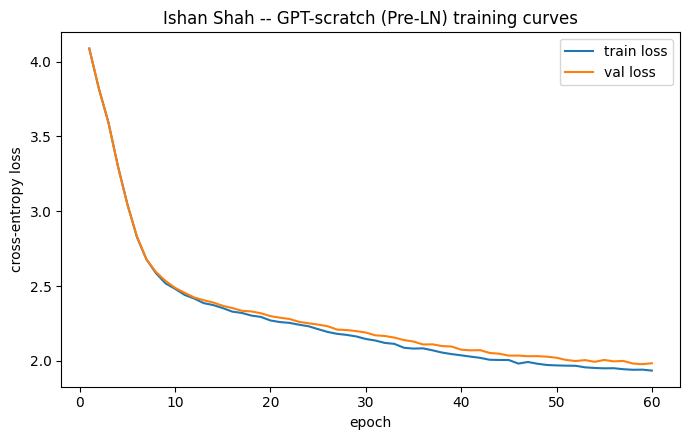

In [6]:
plt.figure(figsize=(7, 4.5))
plt.plot(history["epoch"], history["train_loss"], label="train loss")
plt.plot(history["epoch"], history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Ishan Shah -- GPT-scratch (Pre-LN) training curves")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png"), dpi=130)
plt.show()

### 1.3.5 Text generation

In [7]:
def generate_text(prompt, max_new_tokens=300, temperature=0.8, greedy=False):
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    out = model.generate(idx, max_new_tokens=max_new_tokens, temperature=temperature, greedy=greedy)
    return decode(out[0].tolist())


t0 = time.time()
samples = []
prompts = ["Once upon a time", "The little dog", "One day, a girl"]
for p in prompts:
    samples.append({"prompt": p, "temperature_0.8": generate_text(p, temperature=0.8)})
    samples.append({"prompt": p, "greedy": generate_text(p, greedy=True)})
gen_time = time.time() - t0
gen_chars = sum(len(s.get("temperature_0.8", s.get("greedy", ""))) for s in samples)
gen_tokens_per_sec = gen_chars / gen_time

with open(os.path.join(OUT_DIR, "generated_samples.json"), "w") as f:
    json.dump(samples, f, indent=2)

for s in samples:
    print("-" * 60)
    print(s)

------------------------------------------------------------
{'prompt': 'Once upon a time', 'temperature_0.8': 'Once upon a time was and s.\nShe pome the wand wave had ch ared mard ost to ound he cack.\n\n\n<STO€œHe a wolly the lo witt mare ay bemefr is lakette pp was nourte ighin s cand ober lof imato 6owibly ine itht cho tooo ere, atomed thamanpy?"\n\n\n<STORY_SEPze wo was tre witiqupper re rasothe, the sillr an haw walle fromer '}
------------------------------------------------------------
{'prompt': 'Once upon a time', 'greedy': 'Once upon a time the the was the sar and the was sand and the to the the to the sthe to to the the the wangas the she to the the to the the was the was as the sto the wan the st the to the to the the was the she sand tout the the the was to the the to t the the was the stoul t the the the the sand the was the was t'}
------------------------------------------------------------
{'prompt': 'The little dog', 'temperature_0.8': 'The little dogher aind. Ighe t

### Generation-diversity metrics (distinct-n, repeated 4-gram rate)

In [8]:
def ngrams(seq, n):
    return [tuple(seq[i:i + n]) for i in range(len(seq) - n + 1)]


all_gen_text = "".join(s.get("temperature_0.8", s.get("greedy", "")) for s in samples)
distinct = {}
for n in [1, 2, 3]:
    grams = ngrams(all_gen_text, n)
    distinct[f"distinct_{n}"] = len(set(grams)) / max(1, len(grams))

grams4 = ngrams(all_gen_text, 4)
repeated_4gram_rate = 1 - (len(set(grams4)) / max(1, len(grams4)))

### Final metrics report

In [9]:
final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]
perplexity = math.exp(final_val_loss)
bpc = final_val_loss / math.log(2)
gen_gap = final_val_loss - final_train_loss

metrics_row = {
    "member": "Ishan Shah",
    "architecture": "Pre-LN Transformer, weight-tied head, GELU FFN",
    "n_layer": N_LAYER, "n_head": N_HEAD, "n_embd": N_EMBD, "block_size": BLOCK_SIZE,
    "dropout": DROPOUT, "epochs": N_EPOCHS, "batch_size": BATCH_SIZE, "peak_lr": PEAK_LR,
    "train_loss": final_train_loss,
    "val_loss": final_val_loss,
    "perplexity": perplexity,
    "bits_per_char": bpc,
    "generalization_gap": gen_gap,
    "top1_next_char_acc": history["val_acc"][-1],
    "distinct_1": distinct["distinct_1"],
    "distinct_2": distinct["distinct_2"],
    "distinct_3": distinct["distinct_3"],
    "repeated_4gram_rate": repeated_4gram_rate,
    "grad_norm_mean": sum(grad_norms) / len(grad_norms),
    "grad_norm_max": max(grad_norms),
    "nan_count": nan_count,
    "param_count": n_params,
    "train_tokens_per_sec": train_tokens_per_sec,
    "gen_tokens_per_sec": gen_tokens_per_sec,
    "peak_memory_MB": peak_mem_mb,
    "total_training_time_sec": train_time_sec,
}

import csv
metrics_csv_path = os.path.join(MEMBER_DIR, "metrics_report.csv")
with open(metrics_csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(metrics_row.keys()))
    w.writeheader()
    w.writerow(metrics_row)

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

torch.save(model.state_dict(), os.path.join(CKPT_DIR, "gpt_ishan.pt"))
log_f.close()

print("\n=== FINAL METRICS (Ishan Shah) ===")
for k, v in metrics_row.items():
    print(f"{k}: {v}")


=== FINAL METRICS (Ishan Shah) ===
member: Ishan Shah
architecture: Pre-LN Transformer, weight-tied head, GELU FFN
n_layer: 4
n_head: 4
n_embd: 128
block_size: 128
dropout: 0.1
epochs: 60
batch_size: 64
peak_lr: 0.0003
train_loss: 1.935058832168579
val_loss: 1.9842274188995361
perplexity: 7.273425902819263
bits_per_char: 2.8626350572422687
generalization_gap: 0.04916858673095703
top1_next_char_acc: 0.4040771484375
distinct_1: 0.025396825396825397
distinct_2: 0.1339332980412917
distinct_3: 0.3246822033898305
repeated_4gram_rate: 0.5230524642289348
grad_norm_mean: 0.873933901839603
grad_norm_max: 4.425597072845695
nan_count: 0
param_count: 821632
train_tokens_per_sec: 79748.71287143331
gen_tokens_per_sec: 97.1831006739198
peak_memory_MB: 493.632512
total_training_time_sec: 73.96031594276428
